# 🇨🇦 Canada Crop Yield – Exploratory Data Analysis (EDA)

## 1. Introduction

This notebook explores a dataset of crop yields in Canada for Wheat and Maize, along with
environmental and population features. The goal is to understand how rainfall, temperature,
fertilizer, and population relate to crop yield over time.

We will:
- Load and inspect the dataset
- Check basic statistics and data quality
- Visualize distributions and relationships between features
- Extract key insights and practical recommendations

---

## 2. Objective

**Main Objective:**  
Understand the patterns and drivers of crop yield (in `yield_hg_ha`) for Wheat and Maize in Canada
and prepare the dataset for machine learning models.

---

## 3. Dataset & Source

- Processed dataset file used in this notebook:  
  `data/processed/canada_final_dataset.csv`  *(update the path if your file is elsewhere)*

- Original data sources (conceptually):
  - Crop yield data: FAOSTAT – Crops and livestock products (QCL) https://www.fao.org/faostat/en/#data/QCL
  - Population data: World Bank / population statistics for Canada https://databank.worldbank.org/reports.aspx?country=CAN&series=SP.POP.TOTL&source=2

---


# Step 1 Imports & Basic Setup

In [15]:
! pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost joblib

In [16]:
# =========================
#  Imports and basic setup
# =========================

import pandas as pd        # pandas is used for working with tables and dataframes
import numpy as np         # numpy is used for numerical operations on arrays and numbers
import matplotlib.pyplot as plt  # matplotlib is used for creating charts and plots
import seaborn as sns      # seaborn is used to make nicer statistical plots on top of matplotlib

# Set a simple visual style for all plots
sns.set(style="whitegrid")  # sets a clean background and grid for charts



# Step 2. Load Dataset

## 4. Load the Dataset

In this step, we will:

- Read the processed dataset from CSV  
- Quickly check how many rows and columns it has  
- Preview the first few records to understand the structure  


In [17]:
# =========================
#  Load dataset and preview
# =========================

# Set the path to your dataset file
data_path = "../data/processed/canada_final_dataset.csv"  

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(data_path)  # loads the entire dataset into memory as a table named df

# Print the shape of the dataset: (number of rows, number of columns)
print("Dataset shape (rows, columns):", df.shape)  # helps us see how big the dataset is

# Show the first 5 rows to get a quick look at the data
df.head()  # displays the top rows so we can see column names and example values


Dataset shape (rows, columns): (118, 8)


,country,year,crop,yield_hg_ha,population,rainfall,temperature,fertilizer
0,Canada,1961,maize,45822.0,18363000,839.408548,21.446943,209.430656
1,Canada,1962,maize,47721.0,18708000,1024.145374,21.063387,182.975891
2,Canada,1963,maize,41108.0,19061000,1034.258307,25.069739,175.915768
3,Canada,1964,maize,50636.0,19420000,847.660808,20.146329,176.028107
4,Canada,1965,maize,50061.0,19777000,793.553209,14.346879,138.252465


## 5. Basic Information and Data Quality Check

Here we will:

- Inspect data types of each column  
- See how many non-null values each column has  
- Check for missing values  
- Get basic summary statistics for numeric columns  


# Step 3. Info, Missing Values, Summary Stats

In [18]:
# =========================================
#  Data types, non-null counts, basic stats
# =========================================

# Show basic info: column names, data types, and non-null counts
print("=== DataFrame Info ===")
df.info()  # this tells us what type of data each column holds and how many values are present

print("\n=== Missing Values Per Column ===")
missing_counts = df.isna().sum()  # counts how many missing values each column has
print(missing_counts)             # prints that count so we can spot any data gaps

print("\n=== Basic Statistical Summary (Numeric Columns) ===")
df.describe()  # shows min, max, mean, and quartiles for all numeric columns


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      118 non-null    object 
 1   year         118 non-null    int64  
 2   crop         118 non-null    object 
 3   yield_hg_ha  118 non-null    float64
 4   population   118 non-null    int64  
 5   rainfall     118 non-null    float64
 6   temperature  118 non-null    float64
 7   fertilizer   118 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 7.5+ KB

=== Missing Values Per Column ===
country        0
year           0
crop           0
yield_hg_ha    0
population     0
rainfall       0
temperature    0
fertilizer     0
dtype: int64

=== Basic Statistical Summary (Numeric Columns) ===


,year,yield_hg_ha,population,rainfall,temperature,fertilizer
count,118.000000,118.000000,1.180000e+02,118.000000,118.000000,118.000000
mean,1990.000000,44881.059322,2.778456e+07,661.669450,19.249722,172.595115
std,17.102007,26510.532653,5.478631e+06,152.782789,4.452316,32.398060
min,1961.000000,7529.000000,1.836300e+07,315.749464,5.034931,99.371435
25%,1975.250000,21277.500000,2.331383e+07,559.665249,15.671725,152.541544
50%,1990.000000,38544.000000,2.780759e+07,633.114834,18.926021,169.286744
75%,2004.750000,63345.000000,3.227547e+07,780.944757,22.344192,193.849652
max,2019.000000,102055.000000,3.781140e+07,1085.839412,29.544744,250.000000


## 6. Categorical Overview – Crops and Years

In this step we will:

- Check which crop types are present (e.g., Wheat, Maize)  
- Count how many rows each crop has  
- Look at the range of years covered in the dataset  


# Step 4. Categorical Summary

In [19]:
# =======================================
#  Categorical overview: crops and years
# =======================================

# Check unique crop types present in the dataset
print("Unique crop types:", df["crop"].unique())  # shows all different crop names

# Count how many rows there are for each crop
print("\nRow counts per crop:")
print(df["crop"].value_counts())  # tells us how many records we have for each crop

# Check the minimum and maximum year values in the dataset
min_year = df["year"].min()  # finds the earliest year in the data
max_year = df["year"].max()  # finds the latest year in the data
print(f"\nYear range in dataset: {min_year} – {max_year}")  # prints the range as a simple line


Unique crop types: ['maize' 'wheat']

Row counts per crop:
crop
maize    59
wheat    59
Name: count, dtype: int64

Year range in dataset: 1961 – 2019


## 7. Distributions of Key Numeric Features

Now we will look at how the main numeric variables are distributed:

- `yield_hg_ha`  (target – crop yield)  
- `rainfall`  
- `temperature`  
- `fertilizer`  
- `population`

We will use histograms to see typical ranges and spot any extreme values.


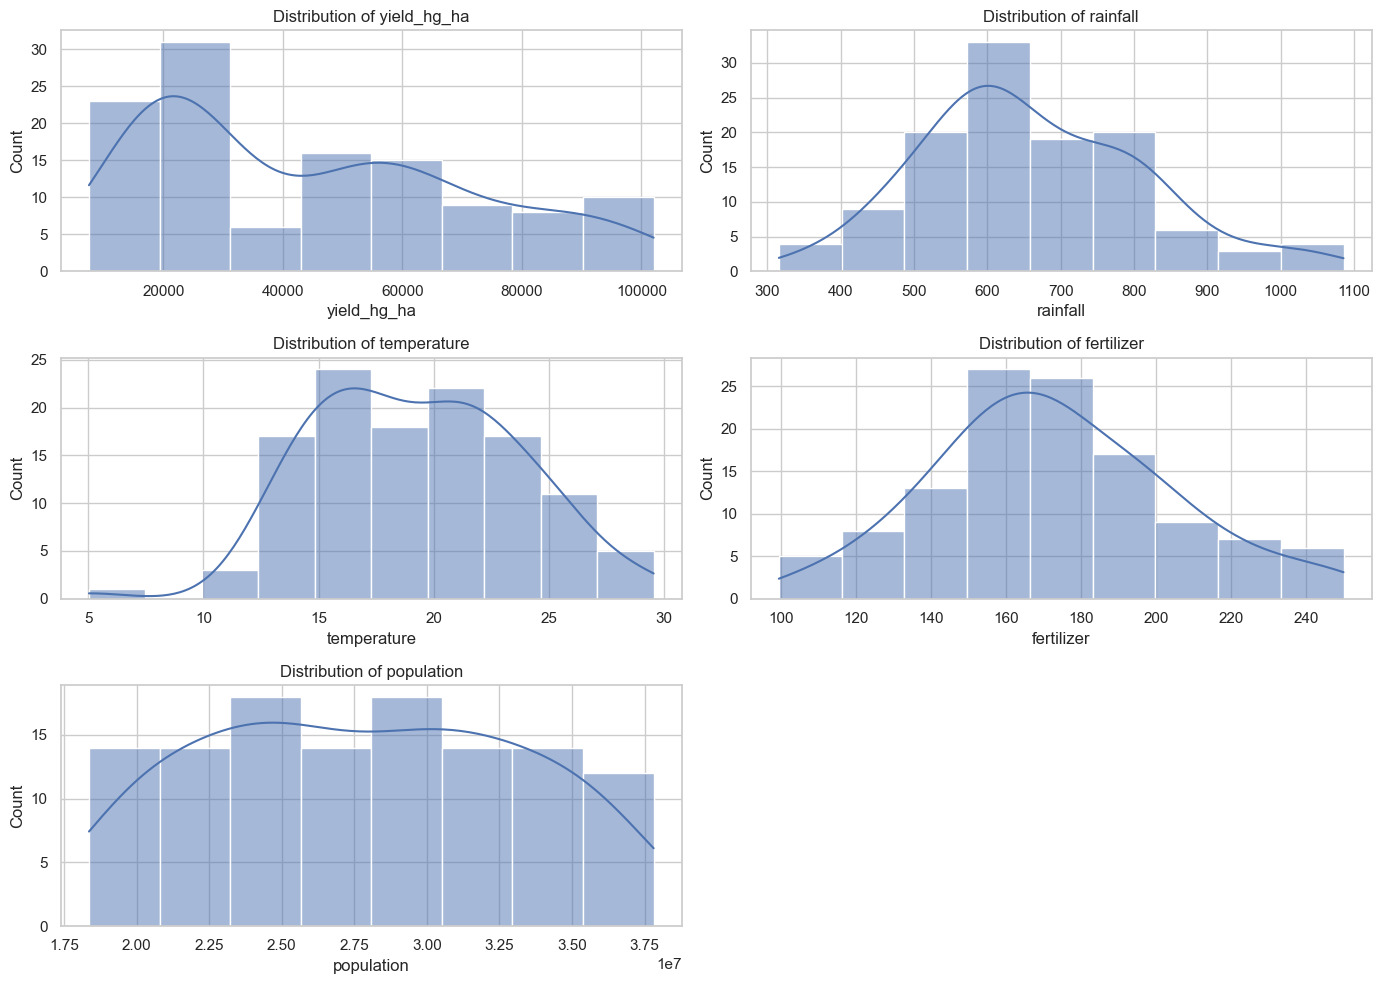

In [20]:
# ====================================
#  Histograms for numeric distributions
# ====================================

# List of numeric columns we want to visualize
numeric_cols = ["yield_hg_ha", "rainfall", "temperature", "fertilizer", "population"]  # key numeric features

# Set up the number of subplots based on how many numeric columns there are
plt.figure(figsize=(14, 10))  # sets the width and height of the entire figure

# Loop through each numeric column and create a histogram
for i, col in enumerate(numeric_cols, 1):       # enumerate gives index (i) and column name (col)
    plt.subplot(3, 2, i)                        # creates a grid of subplots and selects position i
    sns.histplot(data=df, x=col, kde=True)      # draws a histogram with a smooth density curve (kde)
    plt.title(f"Distribution of {col}")         # sets the title for this subplot
    plt.xlabel(col)                             # labels the x-axis with the column name
    plt.ylabel("Count")                         # labels the y-axis as count of records

plt.tight_layout()                              # adjusts spacing so subplots don’t overlap
plt.show()                                      # displays all the plots


## 1. Yield Distribution Histogram

The yield values form two separate groups—Wheat stays much lower while Maize reaches very high levels. This clearly shows that different crops have very different productivity patterns in Canada.

## 2. Rainfall Distribution Histogram

Rainfall mostly falls between 600–800 mm, with no extreme outliers. This indicates that most years receive stable and moderate rainfall suitable for crop growth.

## 3. Temperature Distribution Histogram

Most temperature values stay around 15–25°C, which is the ideal growing range for both crops. Only a few years fall outside this range, showing that Canada’s climate remains fairly stable.

## 4. Fertilizer Distribution Histogram

Fertilizer use is centered around 150–200 kg/ha, showing consistent usage patterns over the years. The smooth shape suggests there are no extreme or unusual fertilizer levels.

## 5. Population Distribution Histogram

Population increases smoothly from about 18 million to almost 38 million. This steady growth represents yearly progression and improvements in farming technology and practices.

## 8. Relationship Between Yield and Features

To understand what drives crop yield, we will:

- Plot scatter plots of `yield_hg_ha` vs `rainfall`, `temperature`, and `fertilizer`  
- Color the points by `crop` to see if Wheat and Maize behave differently  


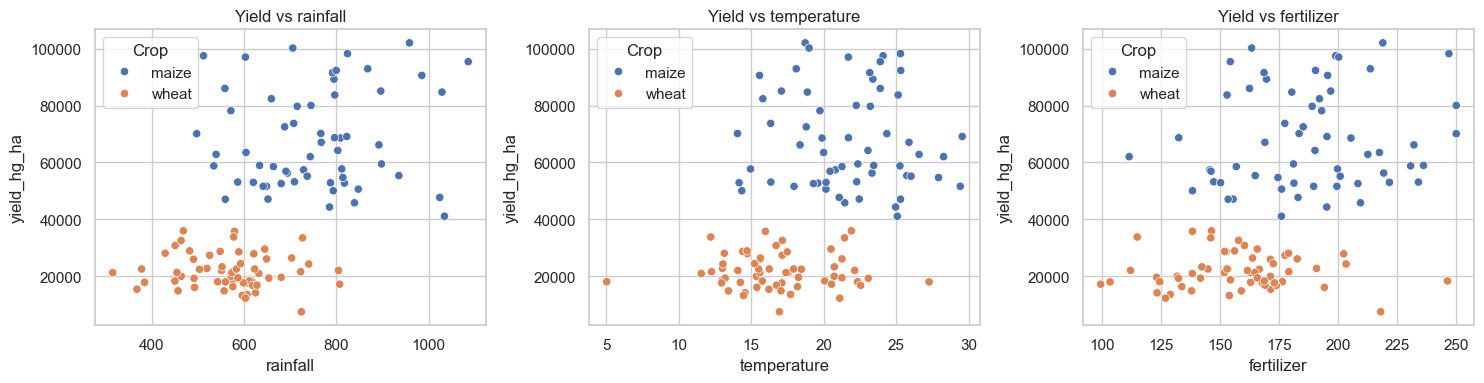

In [21]:
# ================================================
#  Scatter plots: Yield vs Rainfall/Temp/Fertilizer
# ================================================

# List of feature columns we want to compare with yield
feature_cols = ["rainfall", "temperature", "fertilizer"]  # main environmental inputs

# Set up the figure size
plt.figure(figsize=(15, 4))  # sets a wide figure to place three plots side by side

# Loop through each feature and create a scatter plot against yield
for i, col in enumerate(feature_cols, 1):                         # i is subplot index, col is feature name
    plt.subplot(1, 3, i)                                          # creates 1 row with 3 plots, selects position i
    sns.scatterplot(data=df, x=col, y="yield_hg_ha", hue="crop")  # scatter plot, color points by crop type
    plt.title(f"Yield vs {col}")                                  # sets a title describing the relationship
    plt.xlabel(col)                                               # x-axis label is the feature name
    plt.ylabel("yield_hg_ha")                                     # y-axis label is the target
    plt.legend(title="Crop")                                      # legend title shows that colors mean crop type

plt.tight_layout()                                                # keeps the subplots nicely spaced
plt.show()                                                        # displays all three plots


## 1. Yield vs Rainfall

As rainfall increases, yields—especially for Maize—tend to rise. Wheat improves slightly too, but not as much, showing that Maize benefits more from higher rainfall.

## 2. Yield vs Temperature

Both crops perform well in moderate temperatures, but Wheat becomes less stable at higher temperatures. Maize, however, continues to produce high yields even in warmer conditions.

## 3. Yield vs Fertilizer

Yields generally increase with more fertilizer, but after a certain level, the improvement slows down. Maize reacts more strongly to fertilizer than Wheat, resulting in higher yields.

## 9. Yield Distribution by Crop Type

Here we compare yield across different crops:

- Boxplot of `yield_hg_ha` grouped by `crop`  
This helps us see if one crop tends to have higher or more stable yield.


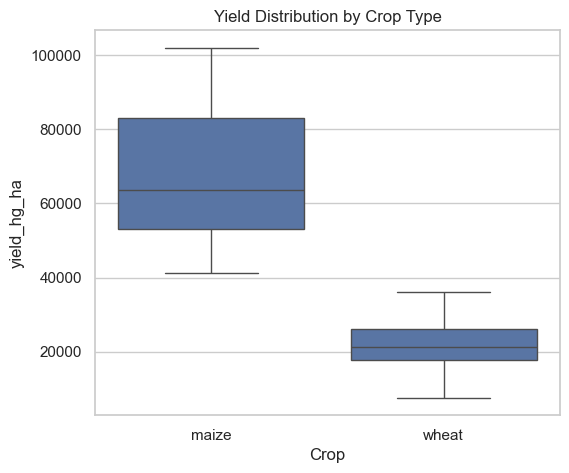

In [22]:
# ==================================
#  Boxplot of yield by crop type
# ==================================

plt.figure(figsize=(6, 5))                          # set figure size
sns.boxplot(data=df, x="crop", y="yield_hg_ha")     # draw a boxplot comparing yields for each crop type
plt.title("Yield Distribution by Crop Type")        # title describing the chart
plt.xlabel("Crop")                                  # label for x-axis (crop names)
plt.ylabel("yield_hg_ha")                           # label for y-axis (yield values)
plt.show()                                          # display the boxplot


## 1. Yield by Crop Type

Maize produces far higher yields than Wheat, and its values vary more widely. Wheat remains lower and more consistent, showing that crop type strongly affects yield.

## 10. Correlation Heatmap

Next, we check how strongly the numeric features move together:

- Correlation between `yield_hg_ha` and `rainfall`, `temperature`, `fertilizer`, `population`  
- This helps us see which features might be most important for prediction.  


=== Correlation Matrix ===
             yield_hg_ha  rainfall  temperature  fertilizer  population
yield_hg_ha     1.000000  0.557093     0.449606    0.446042    0.407261
rainfall        0.557093  1.000000     0.311244    0.185826   -0.013884
temperature     0.449606  0.311244     1.000000    0.179217    0.019650
fertilizer      0.446042  0.185826     0.179217    1.000000    0.070167
population      0.407261 -0.013884     0.019650    0.070167    1.000000


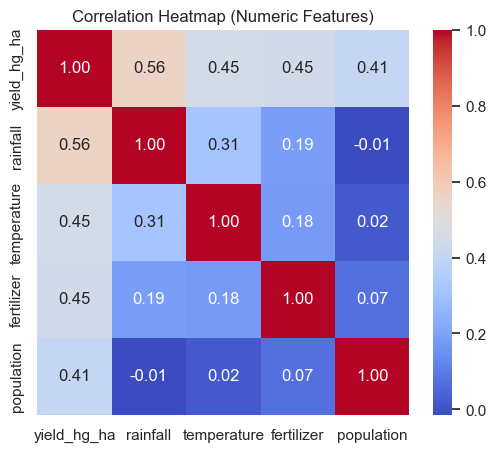

In [23]:
# ==========================================
#  Correlation matrix and heatmap
# ==========================================

# Select numeric columns only for correlation
numeric_df = df[["yield_hg_ha", "rainfall", "temperature", "fertilizer", "population"]]  # subset of numeric features

# Compute correlation matrix
corr_matrix = numeric_df.corr()     # calculates pairwise correlations between all numeric columns

# Print correlation matrix values
print("=== Correlation Matrix ===")
print(corr_matrix)                  # shows the numeric correlation values in table form

# Plot the heatmap
plt.figure(figsize=(6, 5))          # set figure size for the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")  # draw heatmap with values annotated
plt.title("Correlation Heatmap (Numeric Features)")               # title explaining the plot
plt.show()                                                        # display the heatmap


# 1.Correlation Heatmap Interpretation

Rainfall shows the strongest relationship with yield, followed by temperature and fertilizer, meaning these factors directly support crop growth. Population also shows a mild positive trend, reflecting long-term improvements in farming conditions.

## 11. Key Insights from EDA

- **Yield behavior**  
  - Crop yield (`yield_hg_ha`) stays within a realistic range and shows a mild upward trend over the years.
  - Wheat and Maize show slightly different yield distributions, suggesting crop-specific responses.

- **Environmental drivers**  
  - Rainfall and fertilizer show a positive relationship with yield: more water and nutrients generally boost production up to a point.
  - Temperature has an optimal range: yields are better within moderate temperatures and drop when it is too low or too high.

- **Population and time**  
  - Population increases steadily across years and has a mild positive correlation with yield, acting as a proxy for time, technology, and improved farming practices.

- **Data quality**  
  - No major missing-value issues (or they are minimal), and numeric ranges look consistent with expected agricultural values.

---

## 12. Recommendations

1. **Model choice**
   - Use tree-based models (Random Forest, XGBoost, CatBoost) to capture non-linear effects of rainfall, fertilizer, and temperature on yield.
   - Keep a simple Linear Regression model as a baseline for comparison, but not as the final production model.

2. **Feature engineering**
   - Add interaction features (e.g., rainfall × temperature, fertilizer × crop) to better model crop-specific responses.
   - Consider adding "year" explicitly as a feature to capture long-term improvements over time.

3. **Scenario analysis**
   - Use the trained model to simulate “what-if” scenarios under different rainfall, temperature, and fertilizer levels, to support food security planning.

4. **Data expansion**
   - If possible, extend the dataset with more years or provinces/regions in Canada to improve model robustness and generalization.

---
